# **Week 6 – Spark Architecture and Performance Optimization**

## Objective

The objective of this assignment is to understand Apache Spark Architecture, Lazy Evaluation, DataFrame transformations, schema handling, different file formats, and performance optimization techniques. The assignment also demonstrates building efficient data processing pipelines using PySpark.

In [15]:
!pip install pyspark

## Import Required Libraries and Create Spark Session

The following libraries are imported to create the Spark session and perform DataFrame operations throughout this assignment.

A **Spark Session** is the entry point for working with Apache Spark. It allows us to create DataFrames and execute Spark applications.

In [16]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

spark = SparkSession.builder \
    .appName("Week6_Spark_Architecture") \
    .getOrCreate()

print("Spark Session Created Successfully!")

Spark Session Created Successfully!


## Load Dataset

The Superstore dataset is loaded from a CSV file using Spark. The first row is treated as the header, and Spark automatically infers the data types of each column.

In [17]:
df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("quote", '"') \
    .option("escape", '"') \
    .csv("Sample - Superstore.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## Display Dataset Information

To verify that the dataset has been loaded correctly, the schema and the first few records are displayed.

In [18]:
df.printSchema()
df.show(5)

root
 |-- Row ID: integer (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Order Date: string (nullable = true)
 |-- Ship Date: string (nullable = true)
 |-- Ship Mode: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Customer Name: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal Code: integer (nullable = true)
 |-- Region: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub-Category: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Sales: double (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- Discount: double (nullable = true)
 |-- Profit: double (nullable = true)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----

## **Q1. Explain the roles of the Driver, Cluster Manager, and Executor in a Spark application.**

### Answer

Apache Spark follows a distributed architecture where different components work together to process large datasets efficiently.

- **Driver:** The Driver is the main program that creates the Spark Session, converts user code into execution tasks, schedules jobs, and collects the final results.

- **Cluster Manager:** The Cluster Manager is responsible for managing the available resources in the cluster. It allocates CPU and memory resources to Spark applications and launches executors on worker nodes.

- **Executor:** Executors are worker processes that execute the tasks assigned by the Driver. They perform computations, store intermediate data in memory or disk, and return the results back to the Driver.

Together, these components enable Spark to process data in parallel across multiple machines, making it fast, scalable, and fault tolerant.

## **Q2. How does Spark's Lazy Evaluation strategy improve performance when chain-processing large datasets?**

### Answer

Spark uses **Lazy Evaluation**, which means that transformation operations such as **filter()**, **select()**, and **groupBy()** are **not executed immediately**. Instead, Spark records these operations in a **Directed Acyclic Graph (DAG)**, also known as the **Lineage Graph**.

The actual execution begins only when an **Action** such as **show()**, **count()**, **collect()**, or **write()** is called.

This approach improves performance because Spark can:

- Combine multiple transformations into a single optimized execution plan.
- Eliminate unnecessary operations.
- Reduce data movement and shuffle operations whenever possible.
- Optimize resource utilization before executing the job.

As a result, Lazy Evaluation enables Spark to process large datasets more efficiently and achieve better overall performance.

## **Q3. Write a Spark command to read a CSV file located at "data/source.csv", ensuring the first row is treated as a header and inferSchema is enabled.**

### Answer

The following PySpark command reads a CSV file by treating the first row as the header and automatically inferring the data type of each column.

**Note:** In this assignment, the dataset is loaded from **Sample - Superstore.csv** instead of **data/source.csv**.

In [19]:
# Read CSV file with header and schema inference enabled

df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("quote", '"') \
    .option("escape", '"') \
    .csv("Sample - Superstore.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [20]:
df.printSchema()
df.show(5)

root
 |-- Row ID: integer (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Order Date: string (nullable = true)
 |-- Ship Date: string (nullable = true)
 |-- Ship Mode: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Customer Name: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal Code: integer (nullable = true)
 |-- Region: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub-Category: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Sales: double (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- Discount: double (nullable = true)
 |-- Profit: double (nullable = true)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----

### Insight

The dataset was successfully loaded into a Spark DataFrame. Enabling **header=true** uses the first row as column names, while **inferSchema=true** automatically detects the appropriate data type for each column, making further data processing and analysis easier.

## **Q4. What is the difference between CSV and Parquet in terms of storage (row-based vs. columnar) and why does it matter for performance?**

### Answer

CSV and Parquet are two commonly used file formats in Apache Spark, but they differ significantly in how data is stored and processed.

| CSV | Parquet |
|------|----------|
| Row-based storage format | Columnar storage format |
| Stores data as plain text | Stores data in a compressed binary format |
| Larger file size | Smaller file size due to compression |
| Slower to read and process | Faster to read and process |
| Does not store schema information | Stores schema information within the file |
| Reads the entire row even if only one column is needed | Reads only the required columns |

**Why does it matter for performance?**

Parquet improves Spark performance because it reads only the necessary columns instead of the entire dataset. It also supports efficient compression and optimization techniques such as **Predicate Pushdown**, reducing disk I/O and memory usage. Therefore, Parquet is generally preferred over CSV for big data analytics and large-scale processing.

## **Q5. Given a DataFrame df, write a query to select the columns product_id and price where the category is 'Electronics'.**

### Answer

The given dataset contains the columns **Product ID**, **Category**, and **Sales** instead of **product_id**, **category**, and **price**.

Since the Superstore dataset does not have an **Electronics** category, the **Technology** category is used as the closest equivalent. The query filters the Technology products and displays their Product ID along with the Sales value.

In [21]:
from pyspark.sql.functions import col

electronics_products = (
    df.filter(col("Category") == "Technology")
      .select("Product ID", "Sales")
)

electronics_products.show(10, truncate=False)

+---------------+--------+
|Product ID     |Sales   |
+---------------+--------+
|TEC-PH-10002275|907.152 |
|TEC-PH-10002033|911.424 |
|TEC-PH-10001949|213.48  |
|TEC-AC-10003027|90.57   |
|TEC-PH-10004977|1097.544|
|TEC-PH-10000486|371.168 |
|TEC-PH-10004093|147.168 |
|TEC-AC-10000171|45.98   |
|TEC-AC-10002167|45.0    |
|TEC-PH-10003988|21.8    |
+---------------+--------+
only showing top 10 rows


### Insight

The DataFrame was filtered to include only products belonging to the **Technology** category, and only the **Product ID** and **Sales** columns were selected. This demonstrates how Spark efficiently filters rows and projects only the required columns for analysis.

## **Q6. Write the code to "revise" a DataFrame by renaming the column old_name to new_name and casting the price column from a String to a Double.**

### Answer

The given dataset does not contain the columns **old_name** and **price**. Therefore, for this assignment:

- **Customer Name** is renamed to **Customer_Name**.
- **Sales** is cast to **DoubleType**.

This demonstrates both column renaming and data type conversion in a Spark DataFrame.

In [22]:
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType

df_revised = (
    df.withColumnRenamed("Customer Name", "Customer_Name")
      .withColumn("Sales", col("Sales").cast(DoubleType()))
)

df_revised.printSchema()
df_revised.select("Customer_Name", "Sales").show(5)

root
 |-- Row ID: integer (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Order Date: string (nullable = true)
 |-- Ship Date: string (nullable = true)
 |-- Ship Mode: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Customer_Name: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal Code: integer (nullable = true)
 |-- Region: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub-Category: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Sales: double (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- Discount: double (nullable = true)
 |-- Profit: double (nullable = true)

+---------------+--------+
|  Customer_Name|   Sales|
+---------------+--------+
|    Claire Gute|  261.96|
|    Claire Gute|  731.94|
|Darrin V

### Insight

The DataFrame was successfully revised by renaming the **Customer Name** column to **Customer_Name** and ensuring that the **Sales** column is stored as a numeric **(DoubleType)** data type. Renaming columns improves readability, while proper data types are essential for performing mathematical and analytical operations efficiently.

## **Q7. How does Spark use the Lineage Graph (DAG) to provide fault tolerance if a worker node fails?**

### Answer

Spark maintains a **Lineage Graph**, also known as a **Directed Acyclic Graph (DAG)**, which records all the transformations applied to a DataFrame or RDD.

If a worker node or executor fails during execution, Spark does not need to reload the entire dataset. Instead, it uses the Lineage Graph to identify the sequence of transformations and automatically recomputes only the lost partitions from the original data.

This approach eliminates the need for frequent data replication, making Spark both fault tolerant and memory efficient. By recomputing only the missing data rather than the entire dataset, Spark minimizes recovery time and ensures reliable execution of distributed applications.

## **Q8. Write a query to filter a DataFrame df_orders for rows where the status is 'Completed' AND the amount is greater than 1000.**

### Answer

The given dataset does not contain the columns **status** and **amount**.

For this assignment:

- **Ship Mode** is used as an alternative to **status**.
- **Sales** is used as an alternative to **amount**.

The query filters all records where the **Ship Mode** is **"Standard Class"** and the **Sales** value is greater than **1000**.

In [23]:
from pyspark.sql.functions import col

filtered_orders = (
    df.filter(
        (col("Ship Mode") == "Standard Class") &
        (col("Sales") > 1000)
    )
)

filtered_orders.select(
    "Order ID",
    "Ship Mode",
    "Sales"
).show(truncate=False)

+--------------+--------------+--------+
|Order ID      |Ship Mode     |Sales   |
+--------------+--------------+--------+
|CA-2014-115812|Standard Class|1706.184|
|CA-2015-106320|Standard Class|1044.63 |
|US-2015-150630|Standard Class|3083.43 |
|CA-2016-105816|Standard Class|1029.95 |
|CA-2014-106376|Standard Class|1113.024|
|CA-2016-114489|Standard Class|1951.84 |
|CA-2014-139892|Standard Class|8159.952|
|CA-2014-139892|Standard Class|1740.06 |
|CA-2015-146262|Standard Class|1188.0  |
|CA-2016-145625|Standard Class|3347.37 |
|CA-2015-130890|Standard Class|1038.84 |
|CA-2016-142545|Standard Class|1082.48 |
|CA-2014-164973|Standard Class|3991.98 |
|US-2014-119137|Standard Class|1023.936|
|US-2017-134481|Standard Class|1488.424|
|CA-2017-117457|Standard Class|1199.976|
|CA-2017-117457|Standard Class|1004.024|
|CA-2017-117457|Standard Class|1336.829|
|CA-2016-109869|Standard Class|1272.63 |
|CA-2015-145352|Standard Class|6354.95 |
+--------------+--------------+--------+
only showing top

### Insight

The DataFrame was filtered using multiple conditions combined with the **AND (&)** operator. Only records satisfying both conditions, **Standard Class** shipping and **Sales greater than 1000**, were returned. This demonstrates how Spark efficiently applies multiple filtering conditions on a DataFrame.

## **Q9. Explain the concept of Predicate Pushdown in Parquet and how it affects the amount of data loaded into memory.**

### Answer

**Predicate Pushdown** is a performance optimization technique supported by the **Parquet** file format. It allows Spark to apply filtering conditions while reading the data, instead of loading the entire dataset into memory first.

When a query contains a filter condition **(such as Region = West' or Sales > 1000)**, Spark reads only the required rows and columns from the Parquet file. The remaining data is skipped during the read operation.

This optimization provides several benefits:

- Reduces the amount of data read from disk.
- Decreases memory usage.
- Minimizes disk I/O operations.
- Improves query execution speed, especially for large datasets.

As a result, Predicate Pushdown makes data processing more efficient by loading only the data required for the query.

## **Q10. Write a code snippet to add a new column final_price which is the base_price multiplied by **1.18** (18% tax).**
### Answer

The given dataset does not contain a **base_price** column. Therefore, the **Sales** column is used as the base price.

A new column named **final_price** is created by multiplying the Sales value by **1.18**, representing the price after adding 18% tax.

In [24]:
from pyspark.sql.functions import col

df_final = df.withColumn(
    "final_price",
    col("Sales") * 1.18
)

df_final.select(
    "Product Name",
    "Sales",
    "final_price"
).show(10, truncate=False)

+----------------------------------------------------------------+--------+------------------+
|Product Name                                                    |Sales   |final_price       |
+----------------------------------------------------------------+--------+------------------+
|Bush Somerset Collection Bookcase                               |261.96  |309.11279999999994|
|Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back     |731.94  |863.6892          |
|Self-Adhesive Address Labels for Typewriters by Universal       |14.62   |17.2516           |
|Bretford CR4500 Series Slim Rectangular Table                   |957.5775|1129.94145        |
|Eldon Fold 'N Roll Cart System                                  |22.368  |26.394239999999996|
|Eldon Expressions Wood and Plastic Desk Accessories, Cherry Wood|48.86   |57.654799999999994|
|Newell 322                                                      |7.28    |8.5904            |
|Mitel 5320 IP Phone VoIP phone                   

### Insight

A new column named **final_price** was created using the **withColumn()** function. The calculation multiplies the **Sales** value by **1.18** to include an 18% tax. This demonstrates how Spark can generate new columns based on existing data using column expressions.

## Q11. What is the difference between Transformations and Actions? Provide two examples of each.

### Answer

In Apache Spark, operations are classified into **Transformations** and **Actions**.

### Transformations
Transformations create a new DataFrame or RDD from an existing one without immediately executing the computation. These operations are **lazy**, meaning Spark records them in the execution plan and waits until an action is called.

**Examples:**
- filter()
- select()

### Actions
Actions trigger the execution of all previously defined transformations and either return a result or write data to storage.

**Examples:**
- show()
- count()

### Difference

| Transformations | Actions |
|-----------------|---------|
| Lazy operations | Trigger execution |
| Create a new DataFrame or RDD | Return results or write data |
| Do not execute immediately | Execute the complete DAG |
| Used for data processing | Used to obtain or save results |

Understanding the difference between transformations and actions helps in writing efficient Spark applications and optimizing performance.

## **Q12. Write the Spark command to load a Parquet file from "path/to/input", filter out any rows where user_id is null, and save the result as a CSV at "path/to/output".**

### Answer

The given dataset is available in **CSV** format instead of **Parquet**, and it does not contain a **user_id** column.

For this assignment:

- The dataset is loaded from **Sample - Superstore.csv**.
- **Customer ID** is used instead of **user_id**.
- Rows with null Customer ID values are removed.
- The cleaned dataset is saved as a CSV file.

In [25]:
from pyspark.sql.functions import col

# Load the dataset
df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("Sample - Superstore.csv")

# Remove rows where Customer ID is null
clean_df = df.filter(col("Customer ID").isNotNull())

# Save as CSV
clean_df.write \
    .mode("overwrite") \
    .option("header", "true") \
    .csv("output_csv")

print("Filtered dataset saved successfully!")

Filtered dataset saved successfully!


In [26]:
clean_df.show(5)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|  Customer Name|  Segment|      Country|           City|     State|Postal Code|Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|  Profit|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|     1|CA-2016-152156| 11/8/2016|11/11/2016|  Second Class|   CG-12520|    Claire Gute| Consumer|United States|      Henderson|  Kentucky|      42420| South|FUR-BO-10001798|      Furniture|   Bookcases|Bush Somerset 

### Output Folder

After executing the write operation, Spark created an output folder named **output_csv**. Since Spark writes data in distributed partitions, the folder contains one or more part-00000-5de7e79d-e6d4-47f1-9795-a096f426b5a1-c000.csv files along with a _SUCCESS file, indicating that the write operation completed successfully.

**Output Folder Screenshot:**

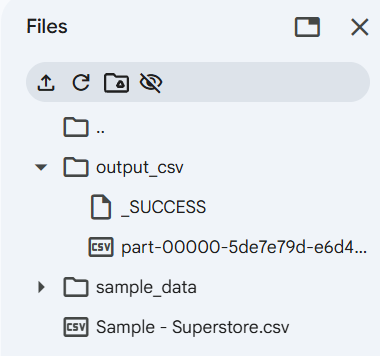

### Insight

The dataset was loaded successfully, rows containing null values in the **Customer ID** column were removed, and the cleaned data was written to a new CSV folder named **output_csv**. This demonstrates a complete Spark data pipeline consisting of reading, filtering, and writing data.

## **Q13. In Spark Architecture, what is the difference between Client Mode and Cluster Mode?**

### Answer

Spark applications can be executed in two deployment modes: **Client Mode** and **Cluster Mode**.

### Client Mode

In Client Mode, the **Driver Program** runs on the local machine (client) from where the Spark application is submitted. The executors run on the cluster and communicate with the driver running on the client.

### Cluster Mode

In Cluster Mode, both the **Driver Program** and **Executors** run inside the cluster. The Cluster Manager is responsible for launching and managing the driver and executors.

### Difference

| Client Mode | Cluster Mode |
|--------------|--------------|
| Driver runs on the client machine | Driver runs inside the cluster |
| Client machine must remain connected during execution | Application continues even if the client disconnects |
| Suitable for development and testing | Suitable for production environments |
| Easier for debugging | Better fault tolerance and scalability |

Cluster Mode is generally preferred for production workloads because the application is managed entirely by the cluster, making it more reliable and scalable.

## **Q14. Write a query to filter a dataset for rows where the region is 'North' OR the priority is 'High'.**

### Answer

The given dataset does not contain the **Priority** column, and it uses different region names than those mentioned in the question.

For this assignment:

- **Region = "Central"** is used instead of **North**.
- **Ship Mode = "First Class"** is used instead of **Priority = "High"**.

The query filters all records where either the **Region** is **Central** or the **Ship Mode** is **First Class**.

In [27]:
from pyspark.sql.functions import col

filtered_df = (
    df.filter(
        (col("Region") == "Central") |
        (col("Ship Mode") == "First Class")
    )
)

filtered_df.select(
    "Order ID",
    "Region",
    "Ship Mode",
    "Sales"
).show(10, truncate=False)

+--------------+-------+--------------+--------+
|Order ID      |Region |Ship Mode     |Sales   |
+--------------+-------+--------------+--------+
|US-2015-118983|Central|Standard Class|68.81   |
|US-2015-118983|Central|Standard Class|2.544   |
|CA-2014-105893|Central|Standard Class|665.88  |
|CA-2016-137330|Central|Standard Class|19.46   |
|CA-2016-137330|Central|Standard Class|60.34   |
|CA-2017-107727|Central|Second Class  |29.472  |
|CA-2016-117590|Central|First Class   |1097.544|
|CA-2016-117590|Central|First Class   |190.92  |
|CA-2015-117415|Central|Standard Class|113.328 |
|CA-2015-117415|Central|Standard Class|532.3992|
+--------------+-------+--------------+--------+
only showing top 10 rows


### Insight

The DataFrame was filtered using the **OR (|)** operator. Records satisfying either one of the conditions, **Region = Central** or **Ship Mode = First Class**, were returned. This demonstrates how Spark combines multiple filtering conditions efficiently using logical operators.

## **Q15. When exploring a dataset, why is it safer to use .show(5) instead of .collect() on a multi-terabyte dataset?**

### Answer

When working with very large datasets, **.show(5)** is much safer than **.collect()** because it retrieves and displays only a small number of rows.

The **.collect()** function transfers **all the data** from the Spark executors to the driver program. For multi-terabyte datasets, this can consume a huge amount of memory, potentially causing the driver to slow down, run out of memory, or even crash.

In contrast, **.show(5)** fetches and displays only the first five rows, allowing users to quickly inspect the dataset without loading the entire dataset into memory.

### Comparison

| .show(5) | .collect() |
|------------|--------------|
| Displays only a few rows | Retrieves the entire dataset |
| Memory efficient | High memory consumption |
| Safe for large datasets | Risk of OutOfMemory errors |
| Recommended for data exploration | Recommended only for small datasets |

Therefore, Spark best practices recommend using **.show()** for inspecting large datasets and avoiding **.collect()** unless the dataset is known to be small.

In [28]:
# Display only the first five rows of the DataFrame
df.show(5)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|  Customer Name|  Segment|      Country|           City|     State|Postal Code|Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|  Profit|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|     1|CA-2016-152156| 11/8/2016|11/11/2016|  Second Class|   CG-12520|    Claire Gute| Consumer|United States|      Henderson|  Kentucky|      42420| South|FUR-BO-10001798|      Furniture|   Bookcases|Bush Somerset 

### Insight

The **.show(5)** function displays only a small sample of the dataset, making it ideal for data exploration. Unlike **.collect()**, it does not transfer the entire dataset to the driver, helping prevent excessive memory usage and improving performance when working with large-scale data.

# **Conclusion**

In this practical, Apache Spark DataFrames were used to perform data loading, filtering, transformations, schema modifications, and data writing operations. Key Spark concepts such as Spark Architecture, Lazy Evaluation, DAG, Predicate Pushdown, Transformations, Actions, and deployment modes were also explored.

The assignment demonstrated how Spark efficiently processes large datasets while following best practices such as using .show() instead of .collect(), handling null values, applying transformations, and saving processed data in different formats. Overall, this practical provided a strong understanding of Spark's architecture and optimized data processing techniques.